## Volcano Plots

In [12]:
library("ggplot2")
library("ggrepel")
library("dplyr")

In [27]:
# data
dirP <- "/sharedscratch/${DATA_DIR}/datasets/hsa-rnaseq-muscle"
dat_ageing <- read.delim(file.path(dirP, "gsea_array/Ageing/mapped_input_results.tsv"), sep = "\t")
dat_atrophy <- read.delim(file.path(dirP, "gsea_array/Atrophy/mapped_input_results.tsv"), sep = "\t")
dat_exercise <- read.delim(file.path(dirP, "gsea_array/Exercise/mapped_input_results.tsv"), sep = "\t")

In [29]:
# function
library("dplyr")
library("ggplot2")
library("ggrepel")

plot_volcano <- function(dat,
                         padj_cutoff = 0.05,
                         lfc_cutoff = 1,
                         top_n = 40,
                         label_col = "SYMBOL",
                         point_size = 1.5,
                         label_size = 3,
                         title = NULL) {
  set.seed(2021)
    
  dat <- dat %>%
    mutate(
      regulation = ifelse(padj < padj_cutoff & log2FoldChange > lfc_cutoff, "UP",
                   ifelse(padj < padj_cutoff & log2FoldChange < -lfc_cutoff, "DOWN", "NS"))
    )
  
  top_genes <- dat %>%
    filter(!is.na(padj), padj > 0, regulation != "NS") %>%
    arrange(padj) %>%
    slice_head(n = top_n)
  
  p <- dat %>%
    ggplot(aes(x = log2FoldChange, y = -log10(padj), color = regulation)) +
    geom_point(size = point_size) +
    scale_color_manual(
      breaks = c("UP", "DOWN", "NS"),
      values = c("red", "blue", "gray")
    ) +
    xlab(expression(log[2](fold-change))) +
    ylab(expression(-log[10](padj))) +
    geom_vline(xintercept = 0, colour = "black", linetype = "longdash") +
    geom_hline(yintercept = -log10(padj_cutoff), colour = "black", linetype = "longdash") +
    theme_classic() +
    geom_text_repel(
      data = top_genes,
      aes(label = .data[[label_col]]),
      size = label_size,
      max.overlaps = Inf,
      box.padding = 0.3,
      point.padding = 0.2,
      show.legend = FALSE
    )
  xlim_val <- max(abs(dat$log2FoldChange), na.rm = TRUE)
  p <- p + coord_cartesian(xlim = c(-xlim_val, xlim_val))
    
  if (!is.null(title)) {
    p <- p + ggtitle(title)
  }
  
  return(p)
}

## Atrophy

Volcano plot showing differential expression results. Each point represents a gene, with log₂(fold change) on the x-axis and −log₁₀(adjusted p-value) on the y-axis. Genes meeting the significance threshold (adjusted p-value < 0.05) and fold change criteria (|log₂FC| > 1) are highlighted as upregulated (red) or downregulated (blue), while non-significant genes are shown in grey. Selected top genes are annotated based on statistical significance.

Warning message:
"Removed 9850 rows containing missing values or values outside the scale range
(`geom_point()`)."


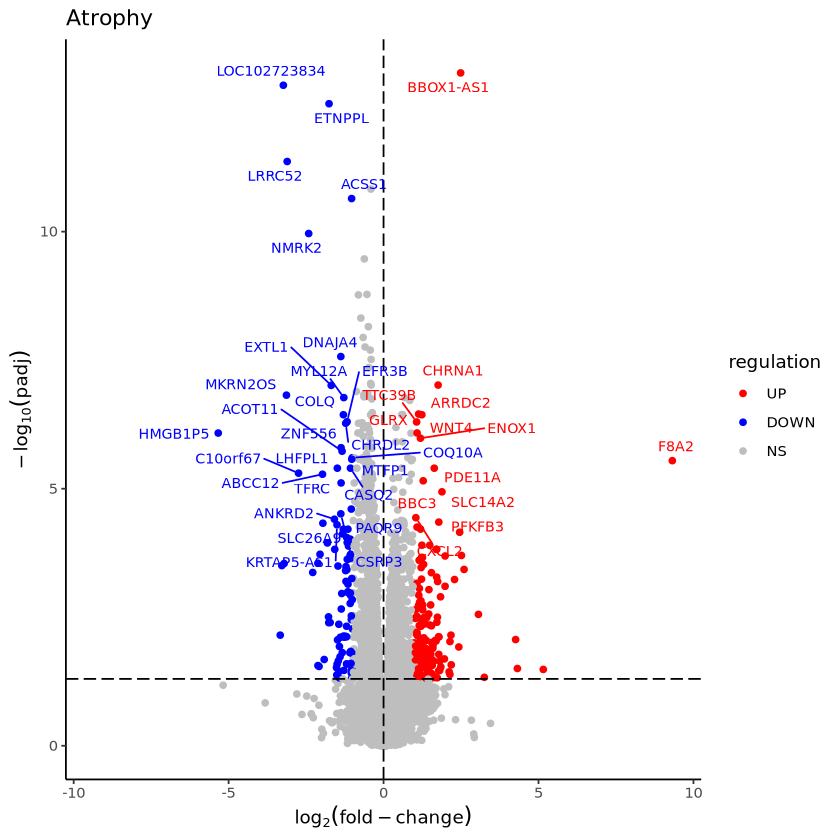

In [30]:
plot_volcano(dat_atrophy, title="Atrophy")

## Ageing

Volcano plot showing differential expression results. Each point represents a gene, with log₂(fold change) on the x-axis and −log₁₀(adjusted p-value) on the y-axis. Genes meeting the significance threshold (adjusted p-value < 0.05) and fold change criteria (|log₂FC| > 1) are highlighted as upregulated (red) or downregulated (blue), while non-significant genes are shown in grey. Selected top genes are annotated based on statistical significance.

Warning message:
"Removed 10966 rows containing missing values or values outside the scale range
(`geom_point()`)."


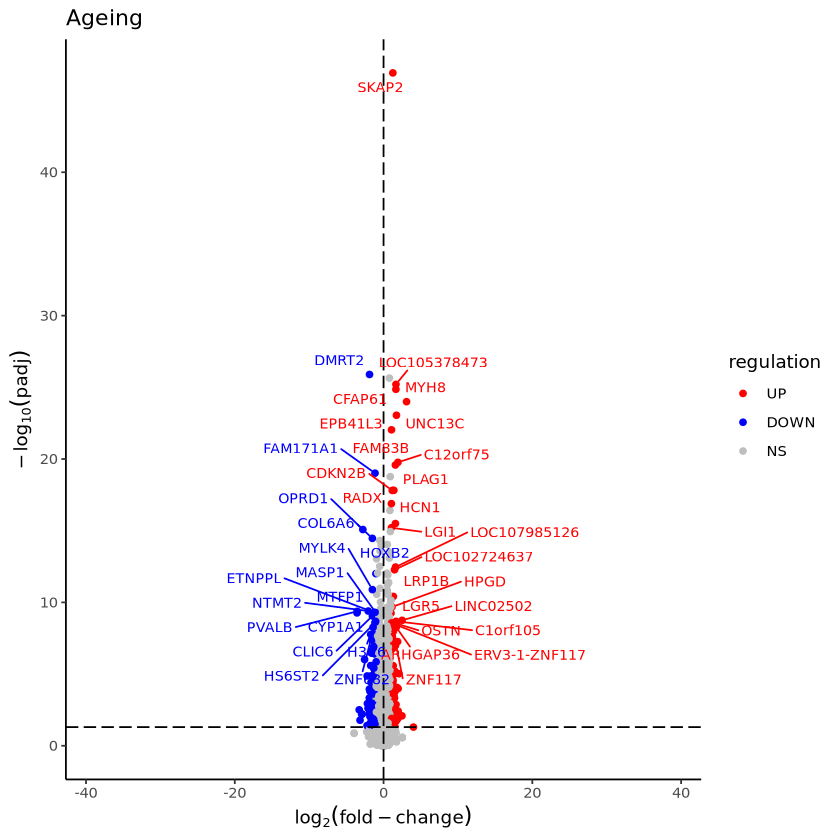

In [32]:
plot_volcano(dat_ageing, title="Ageing")

## Exercise

Volcano plot showing differential expression results. Each point represents a gene, with log₂(fold change) on the x-axis and −log₁₀(adjusted p-value) on the y-axis. Genes meeting the significance threshold (adjusted p-value < 0.05) and fold change criteria (|log₂FC| > 1) are highlighted as upregulated (red) or downregulated (blue), while non-significant genes are shown in grey. Selected top genes are annotated based on statistical significance.

Warning message:
"Removed 11247 rows containing missing values or values outside the scale range
(`geom_point()`)."


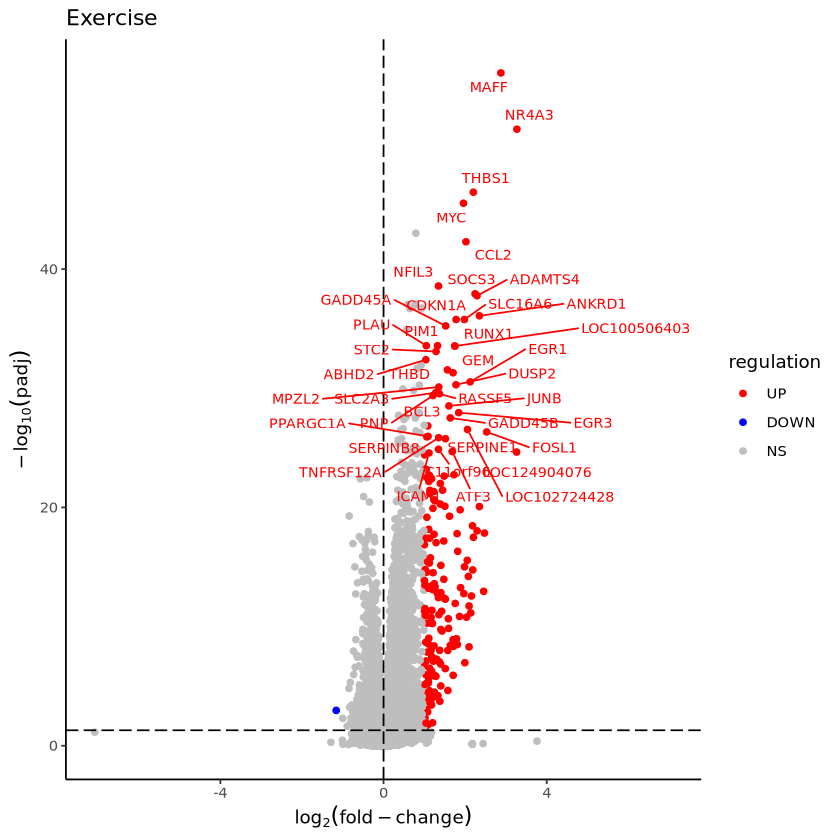

In [34]:
plot_volcano(dat_exercise, title="Exercise")